In [1]:
# temporary imports (should be included in next image iteration)
!pip install matplotlib
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 22.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 25.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.8 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [3]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [4]:
FREESOUND_API_KEY = ""
with open("../fsk.env", "r") as f:
    FREESOUND_API_KEY = f.read().split("=")[1]
    FREESOUND_API_KEY = FREESOUND_API_KEY.replace("\n", "").replace('"','')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [5]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    detect_onsets,
    plot_waveform_with_onsets
)

In [6]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [14]:
# Queries for THIS RUN
freesound_queries = [
    {
        "query": "chopping wood",
        "filter": None,
        "num_results": 20,
    },
]

In [15]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = []
for q in freesound_queries:
    sounds.extend(
        query_freesound(
            query=q["query"],
            filter=q["filter"],
            client=client,
            fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
            num_results=q["num_results"],
        )
    )

print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, AUDIO_DIR)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, AUDIO_DIR)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "queries": freesound_queries,
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

Retrieved 20 sound metadata objects
[1/20] Downloading sound ID 258039
[2/20] Downloading sound ID 378296
[3/20] Downloading sound ID 85534
[4/20] Downloading sound ID 460422
[5/20] Downloading sound ID 638640
[6/20] Downloading sound ID 66113
[7/20] Downloading sound ID 684856
[8/20] Downloading sound ID 512219
[9/20] Downloading sound ID 421928
[10/20] Downloading sound ID 421929
[11/20] Downloading sound ID 553391
[12/20] Downloading sound ID 265035
[13/20] Downloading sound ID 514279
[14/20] Downloading sound ID 386223
[15/20] Downloading sound ID 767432
[16/20] Downloading sound ID 847818
[17/20] Downloading sound ID 766242
[18/20] Downloading sound ID 419928
[19/20] Downloading sound ID 452554
[20/20] Downloading sound ID 669467
Saved metadata CSV: ../data/meta/dataset_2026-04-30_17-46-52.csv
Saved query log JSON: ../data/meta/dataset_2026-04-30_17-46-52.json


In [16]:
!ls ../data/meta

dataset_2026-01-12_16-08-56.csv   dataset_2026-03-18_18-32-10.csv
dataset_2026-01-12_16-08-56.json  dataset_2026-03-18_18-32-10.json
dataset_2026-01-18_13-58-47.csv   dataset_2026-03-18_18-35-35.csv
dataset_2026-01-18_13-58-47.json  dataset_2026-03-18_18-35-35.json
dataset_2026-01-18_19-06-29.csv   dataset_2026-03-18_18-36-36.csv
dataset_2026-01-18_19-06-29.json  dataset_2026-03-18_18-36-36.json
dataset_2026-01-18_19-30-57.csv   dataset_2026-04-30_17-46-52.csv
dataset_2026-01-18_19-30-57.json  dataset_2026-04-30_17-46-52.json


In [27]:
!cat ../data/meta/dataset_2026-04-30_17-46-52.json

{
  "timestamp": "2026-04-30_17-46-52",
  "num_sounds": 20,
  "queries": [
    {
      "query": "chopping wood",
      "filter": null,
      "num_results": 20
    }
  ]
}

In [9]:
delete_dataset_with_gc(META_DIR + "dataset_2026-01-18_18-29-36.csv", META_DIR, AUDIO_DIR, dry_run=False)

Metadata file not found: /workspace/data/meta/dataset_2026-01-18_18-29-36.csv

GC summary:
  Kept audio files: 129
  Deleted audio files: 0


### Show downloaded audio

In [17]:
!ls -lt ../data/audio | head -20

total 13576
-rw-r--r-- 1 root root  25808 Apr 30 17:46 669467_1106446-hq.ogg
-rw-r--r-- 1 root root  11205 Apr 30 17:46 452554_612689-hq.ogg
-rw-r--r-- 1 root root 110629 Apr 30 17:46 419928_8373708-hq.ogg
-rw-r--r-- 1 root root 126825 Apr 30 17:46 766242_15773983-hq.ogg
-rw-r--r-- 1 root root  59786 Apr 30 17:46 847818_16937828-hq.ogg
-rw-r--r-- 1 root root  30052 Apr 30 17:46 767432_7952014-hq.ogg
-rw-r--r-- 1 root root  31819 Apr 30 17:46 386223_1655965-hq.ogg
-rw-r--r-- 1 root root   6653 Apr 30 17:46 514279_632627-hq.ogg
-rw-r--r-- 1 root root 212234 Apr 30 17:46 265035_4759595-hq.ogg
-rw-r--r-- 1 root root  43411 Apr 30 17:46 553391_10912485-hq.ogg
-rw-r--r-- 1 root root   6908 Apr 30 17:46 421929_8090574-hq.ogg
-rw-r--r-- 1 root root   6957 Apr 30 17:46 421928_8090574-hq.ogg
-rw-r--r-- 1 root root  14727 Apr 30 17:46 512219_10756146-hq.ogg
-rw-r--r-- 1 root root   8131 Apr 30 17:46 684856_14887702-hq.ogg
-rw-r--r-- 1 root root  17547 Apr 30 17:46 66113_877451-hq.ogg
-rw-r--r-- 1

In [24]:
# select a file manually
filename = "419928_8373708-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/419928_8373708-hq.ogg'

In [19]:
# select a file randomly
filename = random.choice(os.listdir(AUDIO_DIR))
filename = AUDIO_DIR + filename
filename

'../data/audio/664130_14556113-hq.ogg'

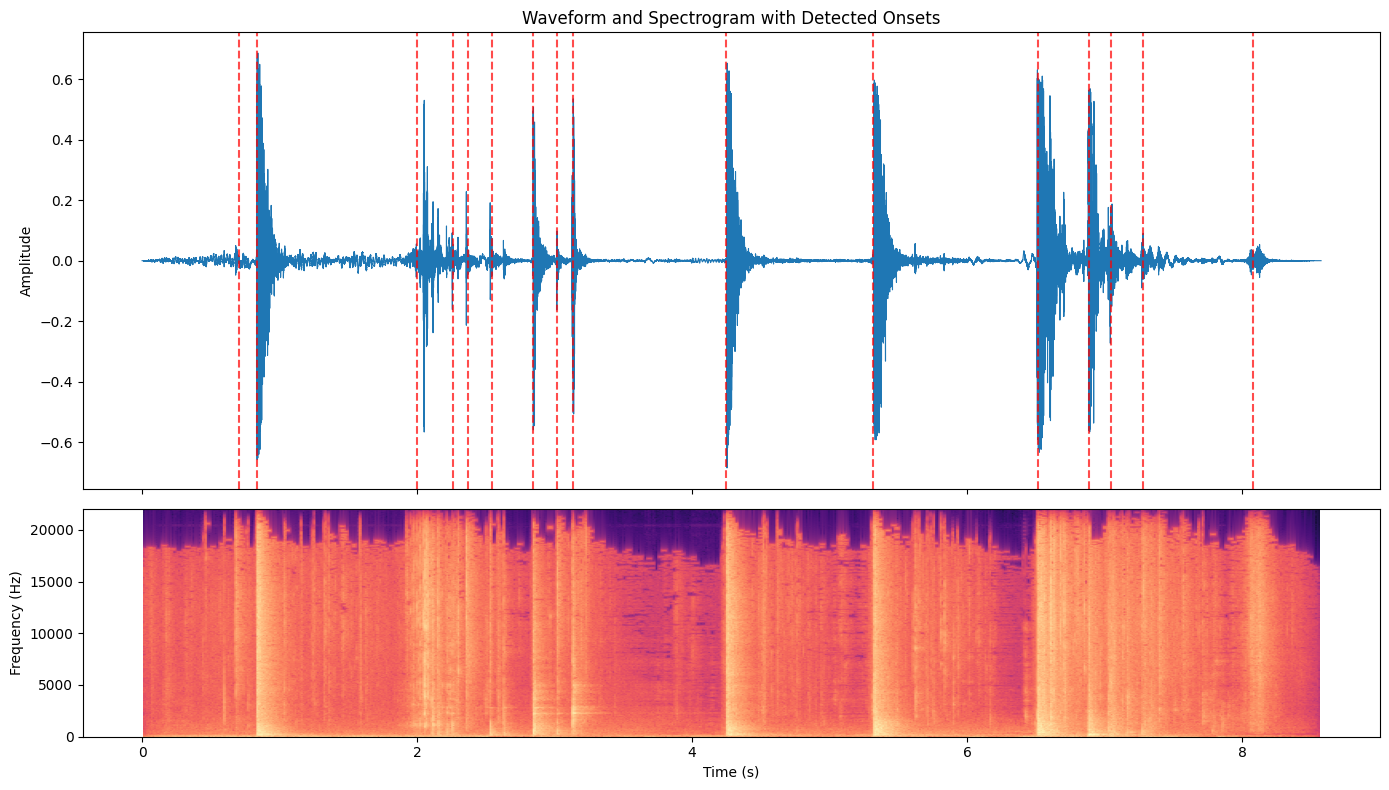

In [25]:
start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filename)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)